# Семинар: Базовый RAG

В рамках ноутбука познакомимся с RAG-системами: их устройством, модификациями, и когда вообще в них возникает необходимость.

In [ ]:
!pip install -U datasets==3.6.0 huggingface_hub fsspec

## 1. Загрузка и подготовка данных

Во-первых, определимся, с какими данными будем иметь сегодня дело.

Будем работать с датасетом на основе телеграм канала, который я ещё заранее спарсила:

In [ ]:
import pandas as pd

df = pd.read_csv('gonzo_dump.csv')
df.head(5)

,Unnamed: 0,id,date,text,word_count
0,0,4058,2025-09-24T22:40:11+00:00,Что-то интересное:\n\nHappy to release Meta Co...,245
1,1,4057,2025-09-23T11:44:54+00:00,Что почитать в дороге,4
2,2,4055,2025-09-22T19:18:08+00:00,Когда же уже R2 наконец?!\n\nDeepSeek-V3.1 → D...,33
3,3,4053,2025-09-22T10:49:48+00:00,"Мы уже писали про варианты JEPA, например, JEP...",42
4,4,4040,2025-09-21T22:40:06+00:00,* **Самодистилляция:** Ещё более удивительно...,232


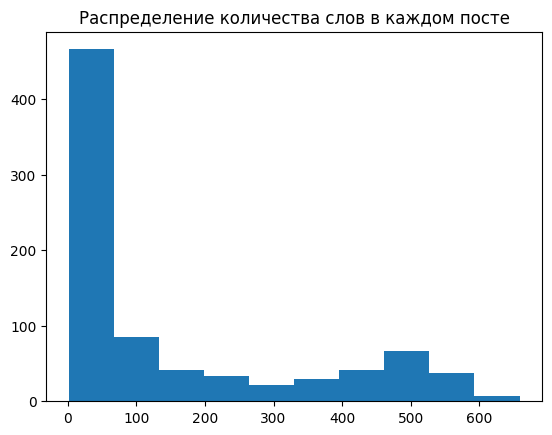

In [ ]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

Попробуем задать вопрос по нашим данным, не используя корректные контексты, в опоре на которые мы могли бы сгенерировать ответы (но не будем).

In [ ]:
longest = df[df['word_count'] > 400].sample(5, random_state=42)['text'].values

for i, text in enumerate(longest):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

Пост номер 1: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

AMD конечно интересны со своей серией MI, в топовой модели MI325

Теперь подгрузим ещё и данные из, т.н. "золотого набора" -- некоторое количество пар вопрос-контекст, на котором мы будем считать "попадания". В моём случае "контекст" в том числе является и ответом, в вашем же случае ответ может отличаться от контекста в пользу большей естественности (это не так важно)

In [ ]:
test_df = pd.read_excel("golden_mock.xlsx")
test_df.head(5)

,question,text
0,"Почему авторы считают, что попытка сохранить в...",Попытка запихнуть весь контекст в скрытое сост...
1,Как устроен механизм Log-Linear Attention и за...,Токены разбиваются на корзинки с экспоненциаль...
2,Как показал себя Log-Linear Attention по сравн...,На синтетике Log-Linear модификация значительн...
3,В чем заключается основная идея сетей Колмогор...,Авторы предлагают альтернативы классическим мн...
4,Как связаны теоремы Цыбенко и Колмогорова-Арно...,Классические MLP опираются на Универсальную те...


In [ ]:
test_df['question'][1]

'Как устроен механизм Log-Linear Attention и за счет чего он достигает сложности `O(L log L)`?'

In [ ]:
# Log Linear Attention

In [ ]:
test_df['text'][1]

'Токены разбиваются на корзинки с экспоненциально растущим числом токенов. Самые свежие токены обычно важнее для предсказания следующего, потому в одной корзине меньше токенов, и, соответственно, их вес больше, а с отдалением от текущей позиции размер корзинок растет, а вклад индивидуальных токенов убывает. Log-Linear attention сначала вычисляет линейный attention по корзинкам, а затем суммирует с некоторыми обучаемыми коэффициентами результат каждой корзинки (коэффициенты предсказывает отдельная MLP). Число корзинок растет логарифмически с длиной - потому и имеем `O(L log L)` как итоговую сложность операции.'

## 2. Простой RAG

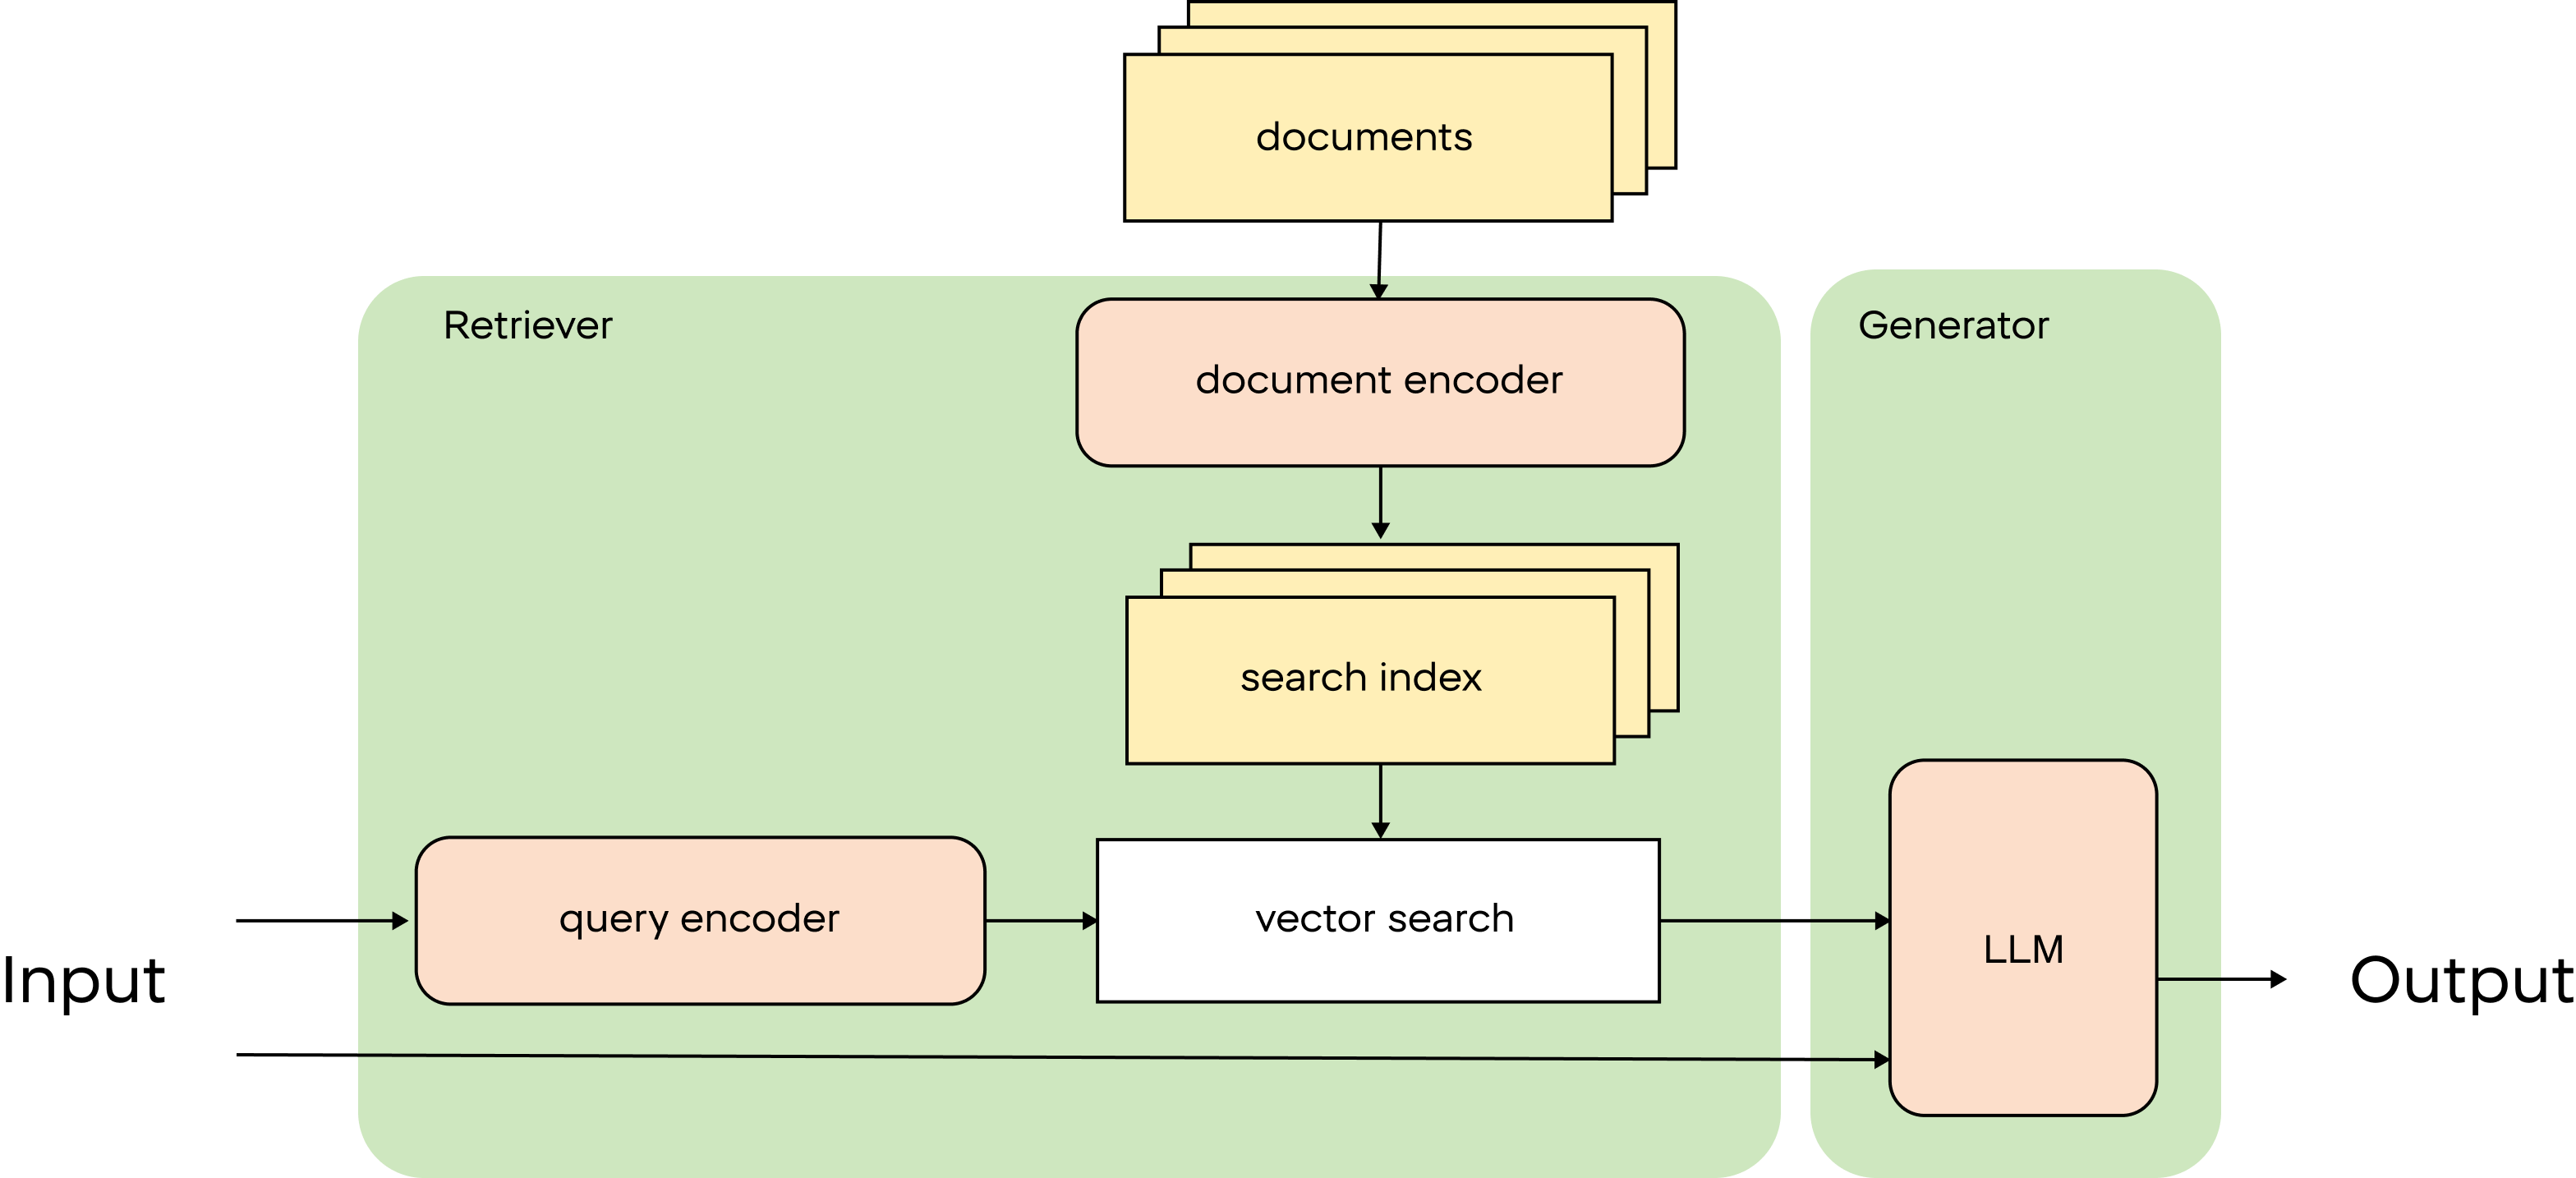

Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks, https://arxiv.org/pdf/2005.11401.pdf

In [ ]:
! pip install qdrant_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.3/337.3 kB 11.6 MB/s eta 0:00:00


In [ ]:
! pip install langchain_huggingface langchain-qdrant

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.2/471.2 kB 27.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.1.4
    Uninstalling huggingface_hub-1.1.4:
      Successfully uninstalled huggingface_hub-1.1.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.4 which is incompatible.


### 2.1. Определение данных

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

In [ ]:
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])

In [ ]:
# symsearch

"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['question'],
        metadata={
            "title": row['id'],
            "text": row['text']
            }
        )
        for i, row in df.iterrows()
    ])

document.metadata['text']
"""

'\ndoc_list = RecursiveCharacterTextSplitter().split_documents([\n    Document(\n        page_content=row[\'question\'],\n        metadata={\n            "title": row[\'id\'],\n            "text": row[\'text\']\n            }\n        )\n        for i, row in df.iterrows()\n    ])\n\ndocument.metadata[\'text\']\n'

In [ ]:
doc_list[0]

Document(metadata={'title': 4058}, page_content="Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https:

In [ ]:
doc_list[0].page_content

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [ ]:
doc_list[0].metadata

{'title': 4058}

### 2.2. Чанкирование

Теперь давайте попробуем посмотреть разные способы разделения текста на куски (они же чанки, от английского chunk). Раасмотрим на примере удобной либы `chonkie`:

In [ ]:
#скачаем, если нужно
!pip install chonkie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.0 MB/s eta 0:00:00


In [ ]:
from chonkie import TokenChunker, SentenceChunker, RecursiveChunker, RecursiveRules, SemanticChunker

**Начнём с `TokenChunker`:**

Самый простой чанкер, который разобьёт наш текст ровно по токенам; поддерживает overlap (пересечение чанков). Это хорошо, когда нам нужен чёткий контроль токенов и его количества, особенно если мы хотим контролировать расходы, работая со внешними нейросетями, однако мы можем потерять часть смысла, разрезав слово на две части.

Подробную документацию можно почитать тут: [TokenChunker](https://docs.chonkie.ai/python-sdk/chunkers/token-chunker)

In [ ]:
token_chunker = TokenChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    chunk_overlap=64
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

2025-11-13 16:53:22.995 | DEBUG    | chonkie.chunker.base:__init__:32 - Initialized TokenChunker


In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

🦛 choooooooooooooooooooonk 100% • 5/5 batches chunked [00:00<00:00, 124.88batch/s] 🌱


Текст номер 1:
Размер чанка: 256
Текст чанка: Когда я в 2018 - м делал свой обзор железа для глубокого обучения ( https : / / moocaholic. medium. com / hardware - for - deep - learning - part - 3 - gpu - 8906c1644664 ), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие - то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли. AMD кон

**Дальше попробуем `SentenceChunker`**:

Этот чанкер обрезает по границам предложения, собирая предложения, пока мы не достигнем целевого размера. Таким образом мы сохраняем целостность одной мысли, не разрезая предложения, как в чанкере выше. Тем не менее, проблема разделения смысла остаётся, так как он может быть размазан по нескольким предложениям, а чанки могут получиться неконсистентными (одни покороче, другие подлиннее) -- из-за этого может быть тяжело следить за количеством токенов, попадающих в модель, а потому может быть тяжелее отслеживать биллинг.

Такой чанкер будет хорош для текстов, где каждое предложение является более-менее оконченной мыслью, преложения либо короткие, либо хотя бы примерно одного размера (не стоит использовать для чанкирования "Войны и Мира"). Кроме того, иногда имеет смысл иметь fallback на случай превышения общего размера токенов, которые мы куда-то передаём (например, топ-5 чанков передаём в LLM)

Документацию можно глянуть тут: [Sentence Chunker](https://docs.chonkie.ai/python-sdk/chunkers/sentence-chunker)

In [ ]:
text_sample = """Пост номер 5: **[GFlowNets]: Flow Network based Generative Models for Non-Iterative Diverse Candidate Generation**
__Emmanuel Bengio, Moksh Jain, Maksym Korablyov, Doina Precup, Yoshua Bengio__
Статья: https://arxiv.org/abs/2106.04399
Код: https://github.com/GFNOrg/gflownet
Пост: https://yoshuabengio.org/2022/03/05/generative-flow-networks/
Короткое саммари от соавтора: https://folinoid.com/w/gflownet/

Давно хотелось написать про **GFlowNets**, или **Generative Flow Networks**, работу в соавторстве Йошуа Бенжио, про которую он крайне тепло отзывается и считает важным новым направлением исследований. По словам Бенжио, среди прочих крутых вещей, работа открывает дорогу к созданию system 2 inductive biases (https://www.microsoft.com/en-us/research/video/gflownets-and-system-2-deep-learning/).

В этом посте в основном про основополагающую работу с NeurIPS 2021. К текущему моменту есть развития, например, “GFlowNet Foundations” (https://arxiv.org/abs/2111.09266), “Multi-Objective GFlowNets” (https://arxiv.org/abs/2210.12765), “A theory of continuous generative flow networks” (https://arxiv.org/abs/2301.12594) и многое другое, особенно в прикладной части с применением к задачам разных областей и особенно для биологии (например, https://arxiv.org/abs/2203.04115).

GFlowNets (GFN) -- генеративные сети, как следует из названия, в которых генеративный процесс представлен транспортной сетью, flow network. Оригинальная работа посвящена генерации молекулярных графов, но в целом GFN годятся для сэмплинга различных комбинаторных объектов.

Цель -- не получить единственную последовательность действий с максимальным reward, а сделать выборку из распределения траекторий, чья вероятность пропорциональна  вознаграждению. Или, другими словами, преобразовать заданную функцию вознаграждения в генеративную policy, сэмплирующую с вероятностью пропорциональной вознаграждению. Это может быть полезно в задачах, где много мод и важна часть про exploration (как раз пример из drug discovery). В одной из последующих работ GFN называют diversity-seeking reinforcement learning algorithms.
"""

In [ ]:
token_chunker = SentenceChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    chunk_overlap=64
)

2025-11-13 16:56:06.722 | DEBUG    | chonkie.chunker.base:__init__:32 - Initialized SentenceChunker


In [ ]:
longest_chunked = token_chunker.chunk(text_sample)

2025-11-13 16:57:36.434 | DEBUG    | chonkie.chunker.sentence:chunk:304 - Chunking text of length 2098
2025-11-13 16:57:36.448 | DEBUG    | chonkie.chunker.sentence:chunk:312 - Prepared 17 sentences for chunking
2025-11-13 16:57:36.463 | INFO     | chonkie.chunker.sentence:chunk:386 - Created 17 chunks from text


In [ ]:
longest_chunked

[Chunk(text='Пост номер 5: **[GFlowNets]: Flow Network based Generative Models for Non-Iterative Diverse Candidate Generation**
 ', token_count=35, start_index=0, end_index=115),
 Chunk(text='__Emmanuel Bengio, Moksh Jain, Maksym Korablyov, Doina Precup, Yoshua Bengio__
 ', token_count=34, start_index=115, end_index=194),
 Chunk(text='Статья: https://arxiv.org/abs/2106.04399 
 ', token_count=20, start_index=194, end_index=236),
 Chunk(text='Код: https://github.com/GFNOrg/gflownet 
 ', token_count=20, start_index=236, end_index=277),
 Chunk(text='Пост: https://yoshuabengio.org/2022/03/05/generative-flow-networks/ 
 ', token_count=27, start_index=277, end_index=346),
 Chunk(text='Короткое саммари от соавтора: https://folinoid.com/w/gflownet/ 
 ', token_count=26, start_index=346, end_index=410),
 Chunk(text='
 Давно хотелось написать про **GFlowNets**, или **Generative Flow Networks**, работу в соавторстве Йошуа Бенжио, про которую он крайне тепло отзывается и считает важным новым направл

In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

2025-11-13 16:56:10.340 | DEBUG    | chonkie.chunker.base:_get_optimal_worker_count:73 - Using 1 workers for parallel processing
2025-11-13 16:56:10.344 | INFO     | chonkie.chunker.base:_parallel_batch_processing:112 - Starting parallel batch processing of 5 texts
🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱2025-11-13 16:56:10.608 | DEBUG    | chonkie.chunker.sentence:chunk:304 - Chunking text of length 3967
2025-11-13 16:56:10.630 | DEBUG    | chonkie.chunker.sentence:chunk:312 - Prepared 45 sentences for chunking
2025-11-13 16:56:10.639 | INFO     | chonkie.chunker.sentence:chunk:386 - Created 15 chunks from text
🦛 choooo                nk  20% • 1/5 docs chunked [00:00<00:01,  3.73doc/s] 🌱2025-11-13 16:56:10.845 | DEBUG    | chonkie.chunker.sentence:chunk:304 - Chunking text of length 4020
2025-11-13 16:56:10.855 | DEBUG    | chonkie.chunker.sentence:chunk:312 - Prepared 31 sentences for chunking
2025-11-13 16:56:10.866 | INFO     | chonkie.chunker.sentenc


Текст номер 1:
Размер чанка: 112
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. 

Размер чанка: 49
Текст чанка: Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? 

Размер чанка: 59
Текст чанка: Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. 

Размер чанка: 117
Текст чанка: NVIDIA долго старалась разделить эти два рынка, и вот сейч

**Теперь `SemantcicChunker`**:

Сохраняем смыслы внутри чанка: делим так, чтобы (по возможности) один смысл == один чанк. Группируем соседние элементы до тех пор, пока внутри семантическая когерентность высокая.

Чанки согласованы семантически -> лучше семантический ретрив; меньше шумных/неинформативных чанков.

В недавних обновлениях библиотеки добавили объединение даже не-соседствующих кусков, и теперь для этого нужно для этого изменить параметр `skip_window` (`0`: склеиваем только последовательные, `1`: группируем разрозненные). Это наследие метода `SDPMChunker` (Semantic Double-Pass Merge), который был убран в недавнем обновлении библиотеки. Если вам важно соседство частей, обратите внимание на этот параметр.

Таким образом, можно использовать этот метод для длинных разнотемных текстов, где темы/подтемы переплетаются (отчёты, форумы, собранные логи, образовательные статьи).

Документация лежит [тут](https://docs.chonkie.ai/python-sdk/chunkers/semantic-chunker).

In [ ]:
token_chunker = SemanticChunker(
    embedding_model="sergeyzh/rubert-mini-frida",
    threshold=0.5,                   # Similarity threshold (0-1) or (1-100) or "auto"
    chunk_size=512,
    min_sentences=1                  # Минимальный размер чанка (в предложениях)
)

modules.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config_sentence_transformers.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

2025-11-13 17:00:16.977 | DEBUG    | chonkie.chunker.base:__init__:32 - Initialized SemanticChunker


In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

2025-11-13 17:00:17.008 | INFO     | chonkie.chunker.base:_sequential_batch_processing:86 - Starting sequential batch processing of 5 texts
🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱2025-11-13 17:00:17.011 | DEBUG    | chonkie.chunker.semantic:chunk:531 - Starting semantic chunking for text of length 3967
2025-11-13 17:00:17.018 | DEBUG    | chonkie.chunker.semantic:chunk:535 - Prepared 41 sentences for semantic analysis
2025-11-13 17:00:17.782 | INFO     | chonkie.chunker.semantic:chunk:573 - Created 10 semantic chunks from 41 sentences
🦛 choooo                nk  20% • 1/5 docs chunked [00:00<00:03,  1.30doc/s] 🌱2025-11-13 17:00:17.784 | DEBUG    | chonkie.chunker.semantic:chunk:531 - Starting semantic chunking for text of length 4020
2025-11-13 17:00:17.789 | DEBUG    | chonkie.chunker.semantic:chunk:535 - Prepared 31 sentences for semantic analysis
2025-11-13 17:00:17.884 | INFO     | chonkie.chunker.semantic:chunk:573 - Created 7 semantic chunks from 31


Текст номер 1:
Размер чанка: 149
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. 

Размер чанка: 157
Текст чанка: Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

**И теперь `RecursiveChunker`**:

Метод разбивает документ по иерархическим уровням (заголовки → параграфы → предложения → токены). Плюс: сохраняет структуру и семантические границы; минус: требует правил для разных форматов и чуть сложнее поддерживать. Используйте для технических доков, markdown/HTML, книг и любых структурированных текстов. Удобно, если формат неизменен, потому что иначе правила могут заскейлиться некорректно или быть неудобными для конкретного формата текста.

Вместе с тем, очевидно, что чанкер не делит текст на куски хоть сколько-то консистентных размеров, так что лучше иметь fallback'и на превышение размера контекстов.

Документацию о RecursiveChunker можно почитать [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker), а о правилах [тут](https://docs.chonkie.ai/python-sdk/chunkers/recursive-chunker#additional-information)


In [ ]:
from chonkie import RecursiveRules, RecursiveChunker

token_chunker = RecursiveChunker(
    tokenizer="sergeyzh/rubert-mini-frida",
    chunk_size=256,
    rules=RecursiveRules(),
    min_characters_per_chunk=24,
)

2025-11-13 17:03:55.645 | DEBUG    | chonkie.chunker.base:__init__:32 - Initialized RecursiveChunker


In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

2025-11-13 17:04:08.936 | DEBUG    | chonkie.chunker.base:_get_optimal_worker_count:73 - Using 1 workers for parallel processing
2025-11-13 17:04:08.939 | INFO     | chonkie.chunker.base:_parallel_batch_processing:112 - Starting parallel batch processing of 5 texts
🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱2025-11-13 17:04:09.085 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chunking for text of length 3967
2025-11-13 17:04:09.093 | INFO     | chonkie.chunker.recursive:chunk:370 - Created 5 chunks using recursive chunking
🦛 choooo                nk  20% • 1/5 docs chunked [00:00<00:00,  6.63doc/s] 🌱2025-11-13 17:04:09.180 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chunking for text of length 4020
2025-11-13 17:04:09.185 | INFO     | chonkie.chunker.recursive:chunk:370 - Created 5 chunks using recursive chunking
2025-11-13 17:04:09.278 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chun


Текст номер 1:
Размер чанка: 243
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.


Размер чанка: 190
Текст чанка:

Можно достать рекурсивный чанкер из готовых рецептов для разной разметки и разных языков, например, вот тут мы загружаем готовый рецепт на markdown разметку:

In [ ]:
token_chunker = RecursiveChunker.from_recipe("markdown")

2025-11-13 17:05:08.876 | INFO     | chonkie.chunker.recursive:from_recipe:115 - Loading RecursiveChunker recipe


v1.schema.json: 0.00B [00:00, ?B/s]

markdown_en.json: 0.00B [00:00, ?B/s]

2025-11-13 17:05:10.700 | DEBUG    | chonkie.chunker.recursive:from_recipe:118 - Recipe loaded successfully with 5 levels
2025-11-13 17:05:10.701 | DEBUG    | chonkie.chunker.base:__init__:32 - Initialized RecursiveChunker


In [ ]:
longest_chunked = token_chunker.chunk_batch(longest)

print()
for i, text in enumerate(longest_chunked):
    print(f"Текст номер {i + 1}:")
    for chunk in text:
        print(f"Размер чанка: {chunk.token_count}")
        print(f"Текст чанка: {chunk.text}")
        print()
    print("="*20)

2025-11-13 17:05:10.745 | DEBUG    | chonkie.chunker.base:_get_optimal_worker_count:73 - Using 1 workers for parallel processing
2025-11-13 17:05:10.747 | INFO     | chonkie.chunker.base:_parallel_batch_processing:112 - Starting parallel batch processing of 5 texts
🦛 ch                    nk   0% • 0/5 docs chunked [00:00<?, ?doc/s] 🌱2025-11-13 17:05:10.781 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chunking for text of length 3967
2025-11-13 17:05:10.787 | INFO     | chonkie.chunker.recursive:chunk:370 - Created 2 chunks using recursive chunking
2025-11-13 17:05:10.791 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chunking for text of length 4020
2025-11-13 17:05:10.793 | INFO     | chonkie.chunker.recursive:chunk:370 - Created 3 chunks using recursive chunking
2025-11-13 17:05:10.797 | DEBUG    | chonkie.chunker.recursive:chunk:368 - Starting recursive chunking for text of length 3305
2025-11-13 17:05:10.799 | INFO     | chonkie.chun


Текст номер 1:
Размер чанка: 1985
Текст чанка: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

AMD конечно интересны со своей

### 2.3. Определение эмбеддингов

Как и датасеты есть 2 типа моделей. Симетричные и асиметричные. В данном примере будут рассмотрены 2 типа моделей:

1. `BAAI/bge-m3` - симметричная, тк не надо добавлять промпты или другие параметры для кодирования запроса. Подробнее прочитать [тут](https://huggingface.co/BAAI/bge-m3).
2. `intfloat/multilingual-e5-large` - асиметричная, тк надо добавлять префикс `query: ` и `passage: ` для кодирования запроса и документа соответственно. Документация лежит [тут](https://huggingface.co/intfloat/multilingual-e5-large).

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [ ]:
# symetric model
embed_model_name = "BAAI/bge-m3"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = {}

# asymetric model
"""
embed_model_name = "intfloat/multilingual-e5-large"
embed_model_kwargs = {'device': device}
encode_kwargs = {"prompt": "passage: "} # prompts
query_encode_kwargs = {"prompt": "query: "} # prompts
"""

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
    query_encode_kwargs=query_encode_kwargs,
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

### 2.3. Определение векторной БД

In [ ]:
qdrant = Qdrant.from_documents(
            doc_list,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [ ]:
qdrant_retriever.invoke("Как быть, если в промптах для LLM содержится нерелевантная информация?")

[Document(metadata={'title': 2100, '_id': '844589c325df4f42b43fb96f8f7a7a35', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нерелев

In [ ]:
results = qdrant.similarity_search(
    "Как быть, если в промптах для LLM содержится нерелевантная информация?", k=2
)
results

[Document(metadata={'title': 2100, '_id': '844589c325df4f42b43fb96f8f7a7a35', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нерелев

Теперь поделим всё на чанки (возьмём PD-retriever, так как он показывает себя достаточно хорошо на длинных текстах)

In [ ]:
# ! pip install langchain_community

In [ ]:
! pip install langchain_core==0.3.77

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.5/449.5 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 1.0.4
    Uninstalling langchain-core-1.0.4:
      Successfully uninstalled langchain-core-1.0.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 1.0.1 requires langchain-core<2.0.0,>=1.0.3, but you have langchain-core 0.3.77 which is incompatible.
langchain-qdrant 1.1.0 requires langchain-core<2.0.0,>=1.0.0, but you have langchain-core 0.3.77 which is incompatible.


In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter()
# This text splitter is used to create the child documents
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                # parent_splitter=parent_splitter,
                verbose=True
            )

In [ ]:
pd_retriever.add_documents(doc_list)

In [ ]:
# PD на коленке
"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])
"""
smaller_doc_list = child_splitter.split_documents([
    Document(
        page_content=doc.page_content,
        metadata={
            "title": doc.metadata['title'],
            "bigger_chunk": doc.page_content,
            }
        )
        for doc in doc_list
    ])

In [ ]:
smaller_doc_list[0].page_content

'Что-то интересное:'

In [ ]:
smaller_doc_list[0].metadata['bigger_chunk']

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [ ]:
document.page_content # -- меньший чанк
document.metadata['bigger_chunk'] # -- больший чанк

### 2.4. Проверка ретрива

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]

# Сюда будем записывать результаты
hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию правильного текста (если есть)
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        if true_text.strip() in txt: # true text ... true text
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:01<00:00, 13.94it/s]


P@k:
P@1: 0.100
P@3: 0.200
P@5: 0.200
P@10: 0.200

⭐ Mean Reciprocal Rank (MRR): 0.142


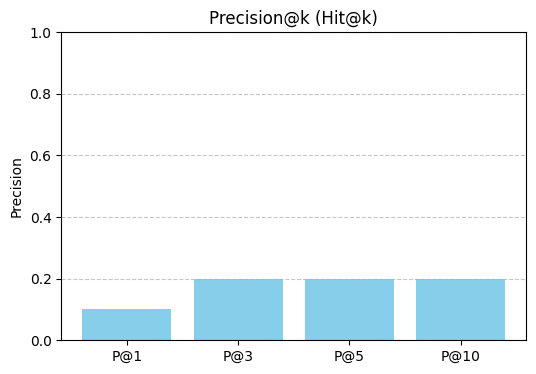

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.9 MB/s eta 0:00:00


In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break
    if rank == 1:
        print(f"question: {question}")
        print(f"context: {retrieved_texts[0]}")

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

 25%|██▌       | 5/20 [00:00<00:02,  6.29it/s]

question: В чем заключается основная идея сетей Колмогорова-Арнольда (KAN) и чем они отличаются от классических MLP?
context: **KAN: Kolmogorov-Arnold Networks**
__Ziming Liu, Yixuan Wang, Sachin Vaidya, Fabian Ruehle, James Halverson, Marin Soljačić, Thomas Y. Hou, Max Tegmark__
Статья: https://arxiv.org/abs/2404.19756 
Код: https://github.com/KindXiaoming/pykan 
Docs: https://kindxiaoming.github.io/pykan/ 
Twitter: https://x.com/zimingliu11/status/1785483967719981538 

~~Yes, we GAN!~~ Yes, we KAN!

Свежую статью про KAN не расшарил за последние дни только ленивый (я — ленивый). Но обзоров по сути при этом довольно мало. Попробуем.

Авторы предлагают альтернативы классическим многослойным персептронам (MLP) под названием **сети Колмогорова-Арнольда (Kolmogorov-Arnold Networks, KANs)**. Идея в том, что фиксированная для нейрона в MLP функция активации в KAN переезжает в изменяемую часть и становится обучаемой функцией (параметризуется сплайном) вместо веса. Это вроде бы небольшое изме

 45%|████▌     | 9/20 [00:01<00:01,  7.77it/s]

question: Что такое structured state space duality (SSD) и какую задачу она решает?
context: Авторы подошли к проблеме фундаментально и предложили фреймворк под названием **structured state space duality (SSD)**,


 75%|███████▌  | 15/20 [00:01<00:00, 11.17it/s]

question: В чем заключается основная идея метода PathFinder и как он отличается от других подходов к многоходовому рассуждению?
context: **PathFinder: Guided Search over Multi-Step Reasoning Paths**
__Olga Golovneva, Sean O'Brien, Ramakanth Pasunuru, Tianlu Wang, Luke Zettlemoyer, Maryam Fazel-Zarandi, Asli Celikyilmaz__
Статья: https://arxiv.org/abs/2312.05180 

Активно развивается тема многоходовых генераций через LLM. Здесь уже были Tree-of-Thought (https://t.me/gonzo_ML/1885), есть Graph-of-Thoughts (https://arxiv.org/abs/2308.09687) и даже Everything-of-Thought (https://arxiv.org/abs/2311.04254) с применением MCTS. Взбудораживший общественность Q* от OpenAI (https://www.technologyreview.com/2023/11/27/1083886/unpacking-the-hype-around-openais-rumored-new-q-model/) предположительно тоже связан с многоходовым планированием в LLM. Если посмотреть глобально, то оно всё ложится в концепцию LLM Programs (https://t.me/gonzo_ML/1584). 

FAIR предложили свой подход к многоходовой генерации

 95%|█████████▌| 19/20 [00:02<00:00,  8.83it/s]

question: В чем заключается основная идея метода MatQuant?
context: **Метод**

MatQuant по постановке ,поверх о**птимизируемых методов квантизации**, с обучаемыми непрерывными или дискретными параметрами.

Основная идея работы в том, что для целочисленных типов данных отстругивая младшие биты от представления с максимальной бытностью, возможно получать приближения разной точности, вложенные друг в друга, как матрешка.

Но если просто огрублять, скажем , int8 квантизацию, работает не очень, поэтому предлагается совместно оптимизировать разные битности одновременно в одном батче с разными весами. 

MatQuant применяют поверх [OmniQuant](https://arxiv.org/abs/2308.13137), в котором оптимизируются скейлы и biasы в квантизации через поблочную дистилляцию, и **QAT**, которая суть просто обучение (с кроссэнтропийным лоссом) с STE через недифференцируемую операцию квантизации.

**Эксперименты**

Метод валидируют преимущественно на Gemma 2 (2b и 9b) моделях и Мистрале 7b. Полагаю, что 🦙 и Квены 

100%|██████████| 20/20 [00:02<00:00,  8.52it/s]


P@k:
P@1: 0.300
P@3: 0.600
P@5: 0.650
P@10: 0.750

⭐ Mean Reciprocal Rank (MRR): 0.464


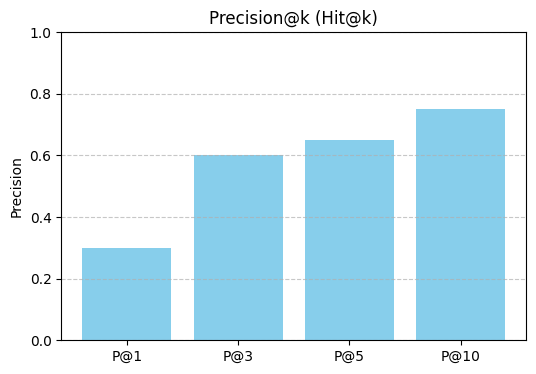

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:02<00:00,  9.24it/s]


P@k:
P@1: 0.450
P@3: 0.650
P@5: 0.650
P@10: 0.650

⭐ Mean Reciprocal Rank (MRR): 0.550


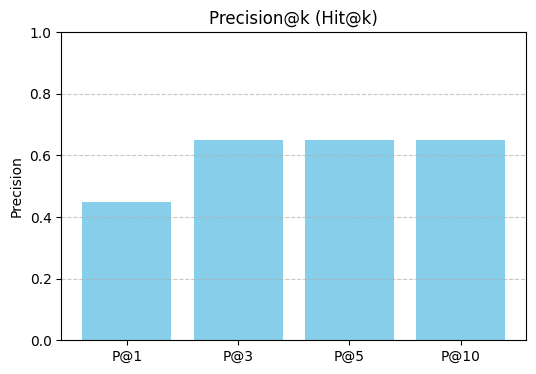

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
! pip install rank_bm25

In [ ]:
!pip install langchain_community

  Using cached langchain_core-1.0.4-py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.6 MB/s eta 0:00:00
Using cached langchain_core-1.0.4-py3-none-any.whl (471 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.77
    Uninstalling langchain-core-0.3.77:
      Successfully uninstalled langchain-core-0.3.77
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.3.11
    Uninstalling langchain-text-splitters-0.3.11:
      Successfully uninstalled langchain-text

In [ ]:
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.4, 0.6],  # BM25 + Qdrant
)

In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = ensemble_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:04<00:00,  4.33it/s]


P@k:
P@1: 0.450
P@3: 0.600
P@5: 0.600
P@10: 0.600

⭐ Mean Reciprocal Rank (MRR): 0.512


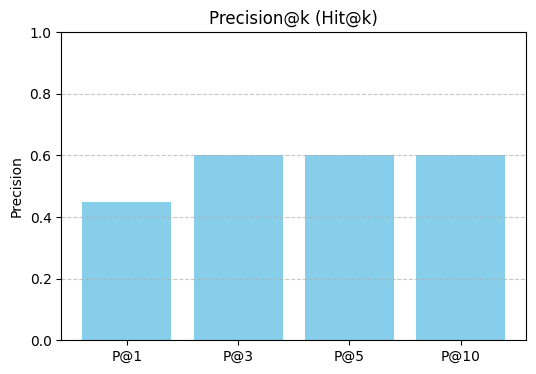

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


100%|██████████| 20/20 [00:01<00:00, 15.55it/s]


P@k:
P@1: 0.400
P@3: 0.500
P@5: 0.500
P@10: 0.550

⭐ Mean Reciprocal Rank (MRR): 0.438


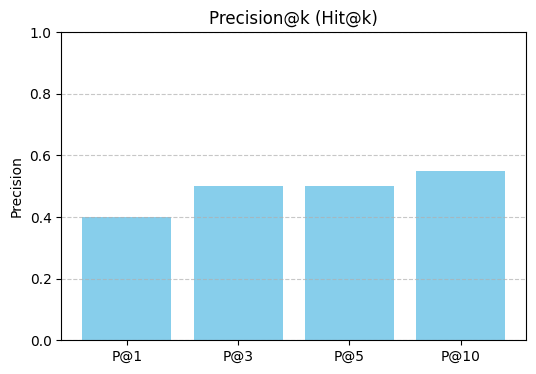

In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = bm25_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 3. Модификации RAG

### 3.1. Query Expansion

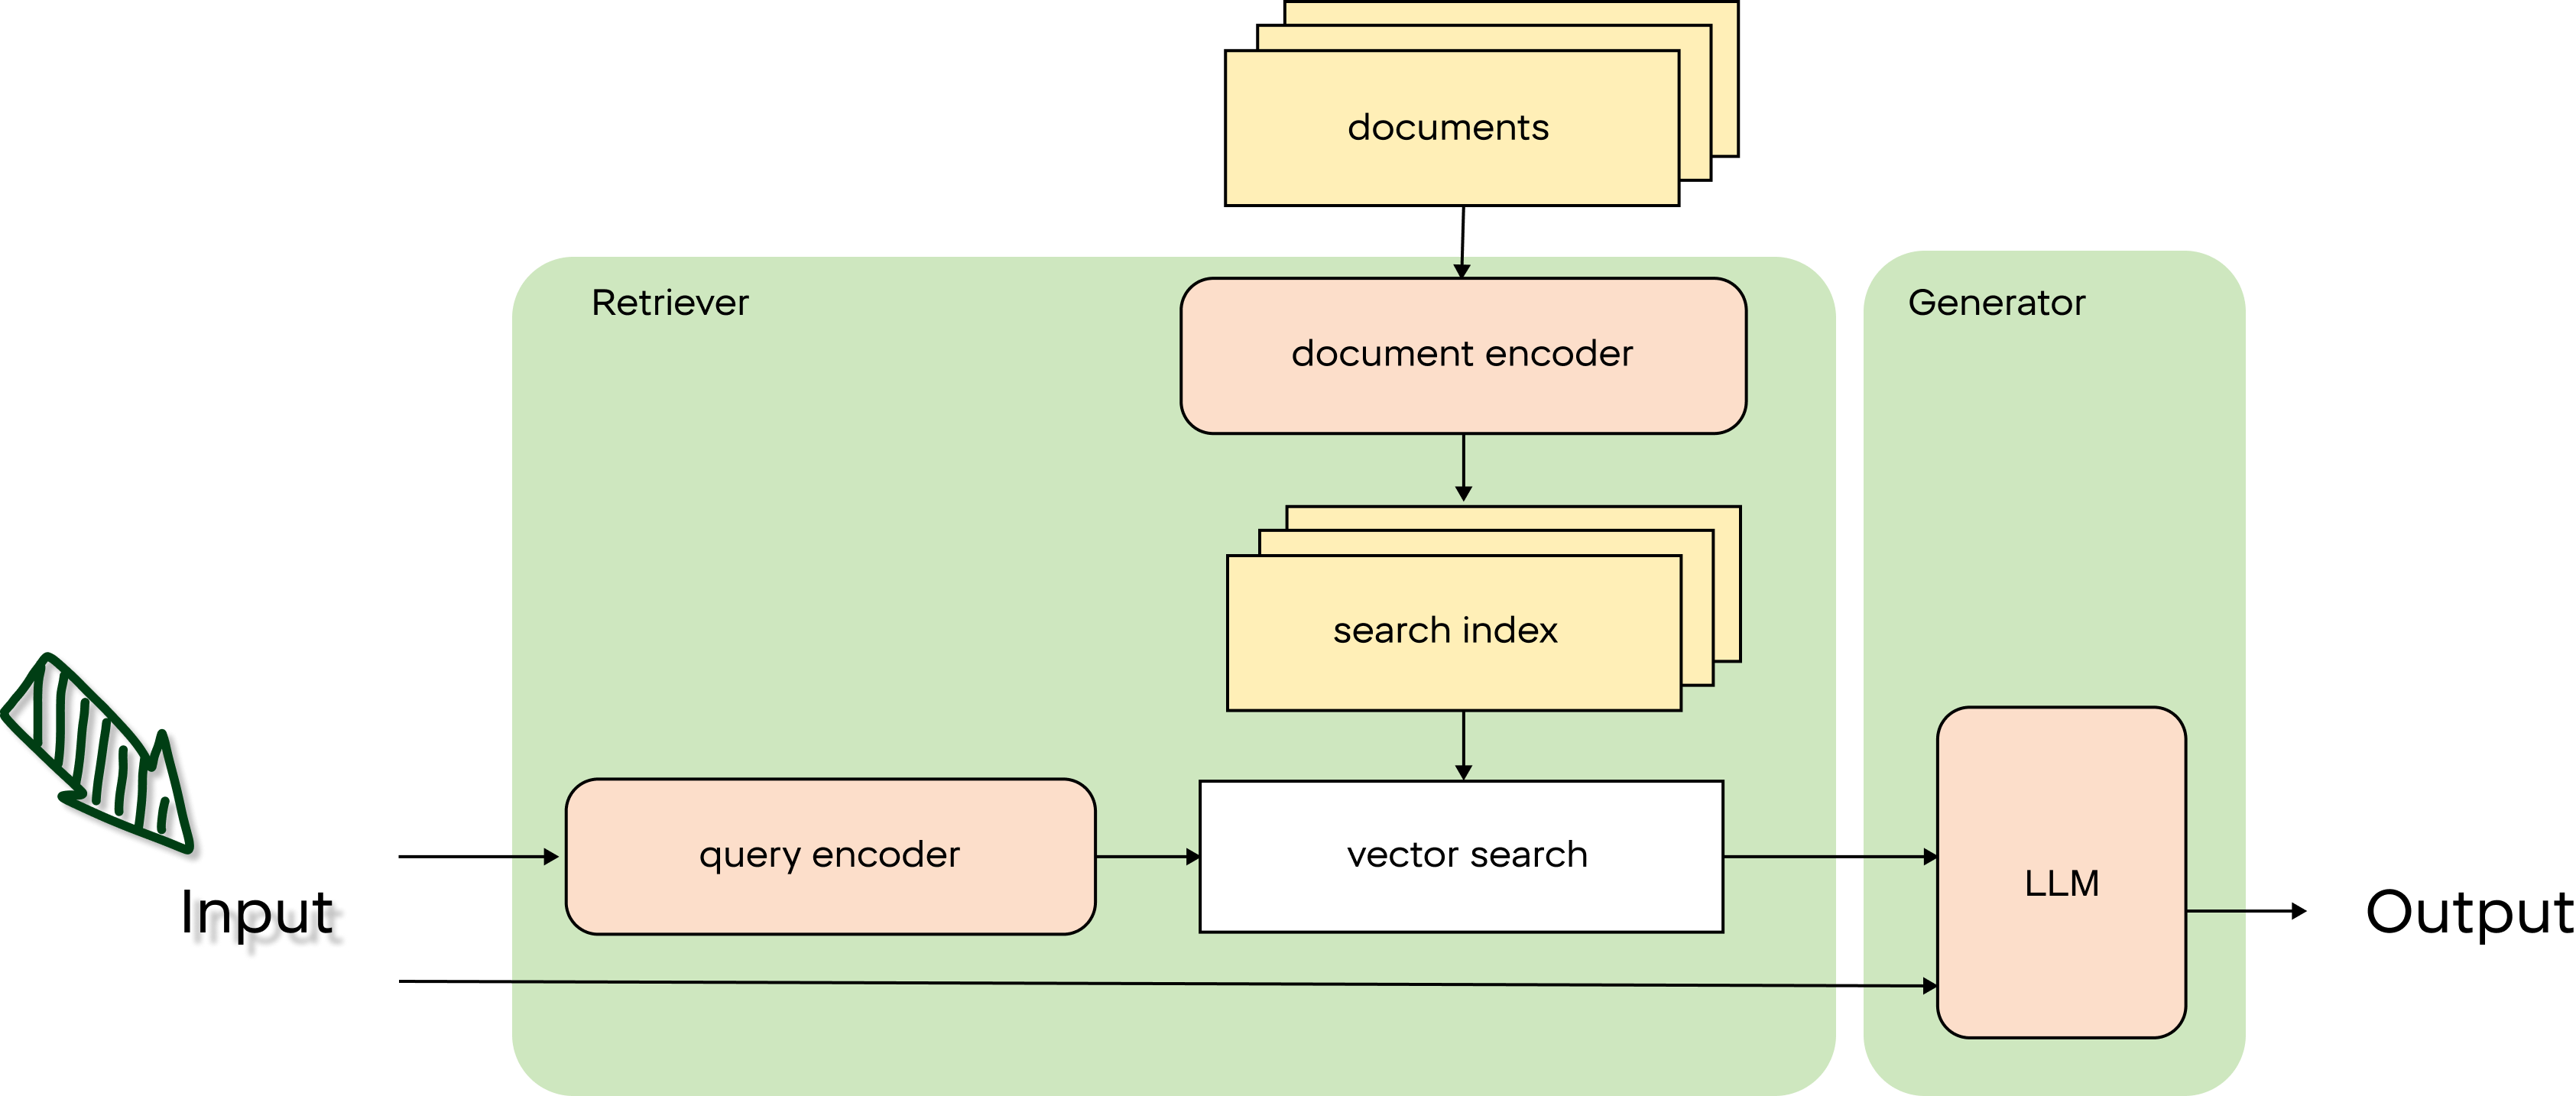

Часто случается так, что пользователи задают вопросы совсем не так, как мы ожидаем: с опечатками, неполно, неграмотно, и с этим нужно уметь работать (потому что у нас нет выбора).

Как правило, проблему с нестандартными, но полными запросами мы решаем перефразированием вопроса пользователя:

In [ ]:
from transformers import pipeline
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

cuda


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

Device set to use cuda


In [ ]:
original = "чё делать если в промптах нерелевантная инфа?"
messages = [
    {"role": "system", "content": "Ты LLM-инженер и должен перефразировать вопросы пользователя, исправив грамматику, но не меняя смысл."},
    {"role": "user", "content": original},
]

paraphrased = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
print(paraphrased)

Как следует поступить, если в промптах присутствуют ненужные или не относящие к делу данные?


### 3.2. Reranking

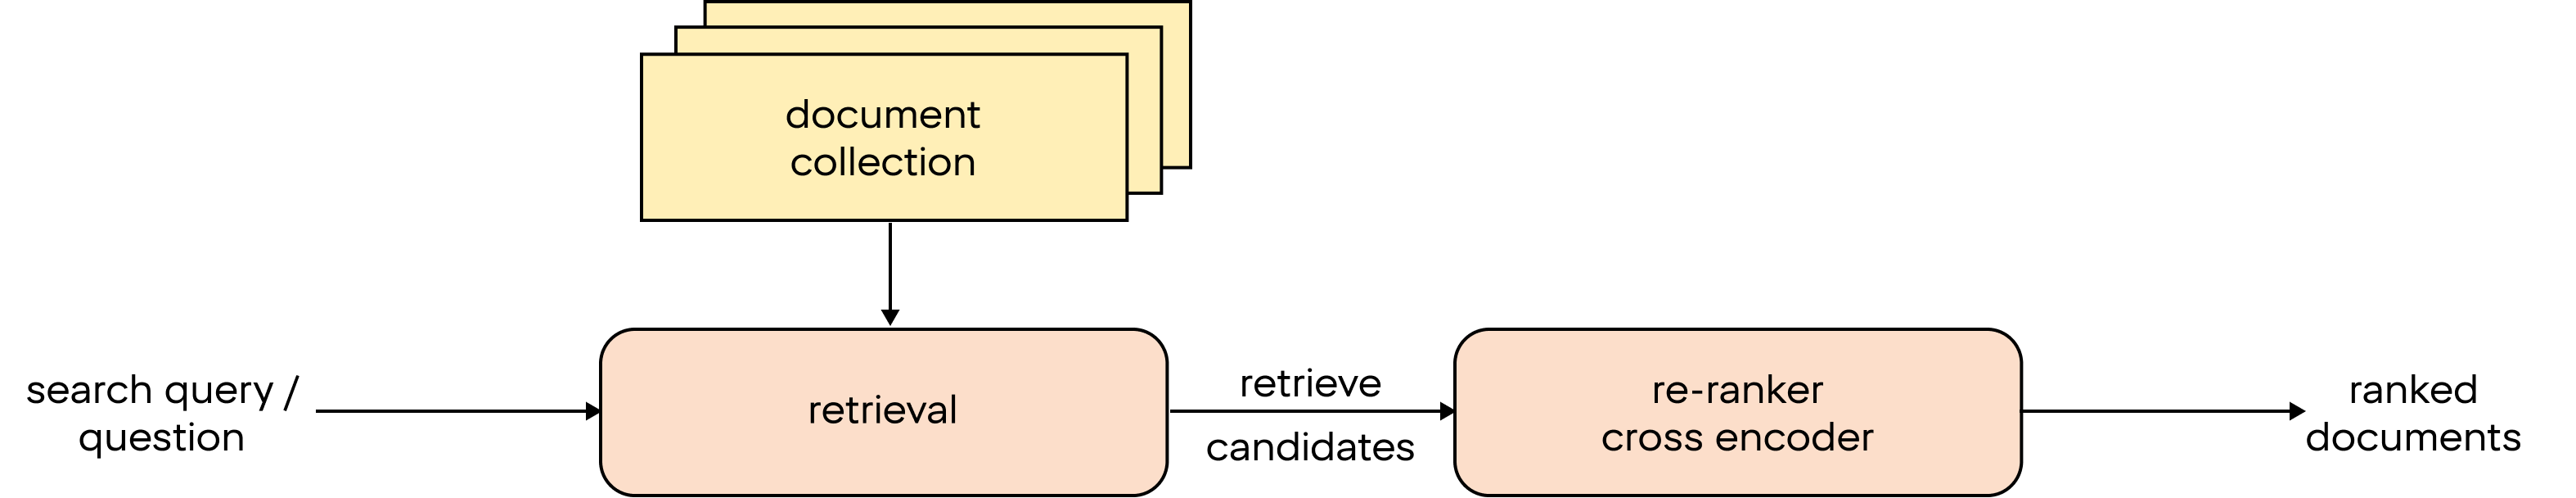

Reranker – это языковая модель, принимающая два текста и возвращающая близость между ними. В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей amberoad/bert-multilingual-passage-reranking-msmarco.

In [ ]:
#! pip install langchain_community

In [ ]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [ ]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='BAAI/bge-reranker-v2-m3',
    model_kwargs={'device': device}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

567755777

In [ ]:
import numpy as np

k_values = [1, 3, 5, 10, 20]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]
    scores = cross_encoder.score([(question, text) for text in retrieved_texts])
    idxs = np.argsort(scores)[::-1][:max(k_values)]

    new_texts = [retrieved_texts[i] for i in idxs]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(new_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:09<00:00,  2.03it/s]


P@k:
P@1: 0.550
P@3: 0.650
P@5: 0.650
P@10: 0.650
P@20: 0.650

⭐ Mean Reciprocal Rank (MRR): 0.600


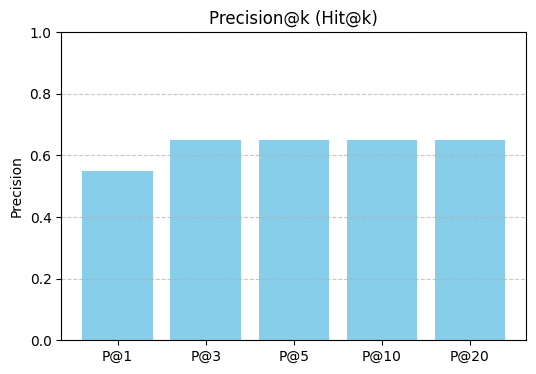

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Bonus: LLM-as-a-judge

####Коэффициент Коэна κ (Cohen’s Kappa)


**Коэффициент Коэна κ** — мера согласия **двух аннотаторов** (или двух «судей») при категоризации объектов, **скорректированная на случайное совпадение**.

* Пусть есть два набора меток для N объектов: (A) и (B).
* (p_o) — наблюдаемая доля совпадений (accuracy).
* (p_e) — ожидаемая доля совпадений «по случаю» (исходя из частот классов у каждого аннотатора).

Тогда:
$$
\kappa ;=; \frac{p_o - p_e}{1 - p_e}.
$$

* Если (\kappa = 1): полное согласие (лучше не бывает).
* Если (\kappa = 0): согласие не лучше случайного.
* Если (\kappa < 0): хуже случайного — систематическое расхождение.

**Интерпретация (популярная шкала Landis & Koch, условная!)**

* **< 0.00** — плохое
* **0.00–0.20** — слабое
* **0.21–0.40** — удовлетворительное
* **0.41–0.60** — умеренное
* **0.61–0.80** — существенное
* **0.81–1.00** — почти идеальное

> Важно: κ чувствителен к **дисбалансу классов** и **смещению порогов**. Если один аннотатор чаще ставит «релевантно», чем другой, κ может снижаться, даже при высокой точности.


#### Другие советы:

* Для LLM-судьи ставьте **temperature=0** и требуйте **строгий JSON** — меньше дрейфа.
* Снижайте стоимость: сначала **retrieval → rerank (cross-encoder)**, и уже **на top-10** зовите LLM-judge.

### Быстрый чек-лист по базовым RAG техникам и их выбору:

1. Есть ли внешние документы, от которых зависит правильность ответа?
    * Да; Объём документов больше контекстного окна модели?
        * Да → нужен RAG, ретривер/чанкирование.
        * Нет → можно попытаться засунуть все документы в системный промпт.
    * Нет; Не используем контексты при генерации
2. Запрос короткий и отличается от формулировок в документах?
    * Да, несильно → подумай о различных энкодерах, query expansion, reranker.
    * Да, сильно → скорее всего стоит использовать симметричный поиск вместо асимметричного
3. Нужно цитирование / трассируемость?
    * Да → делай RAG (с сохранением источников).
4. Домены с высокой ценой ошибки?
    * Да → RAG + строгая инструкция «опираться только на контекст».

А что если пользователи могут задавать оба вида вопросов, и мы хотим уметь отвечать на оба? Да давайте просто всё в RAG засунем...

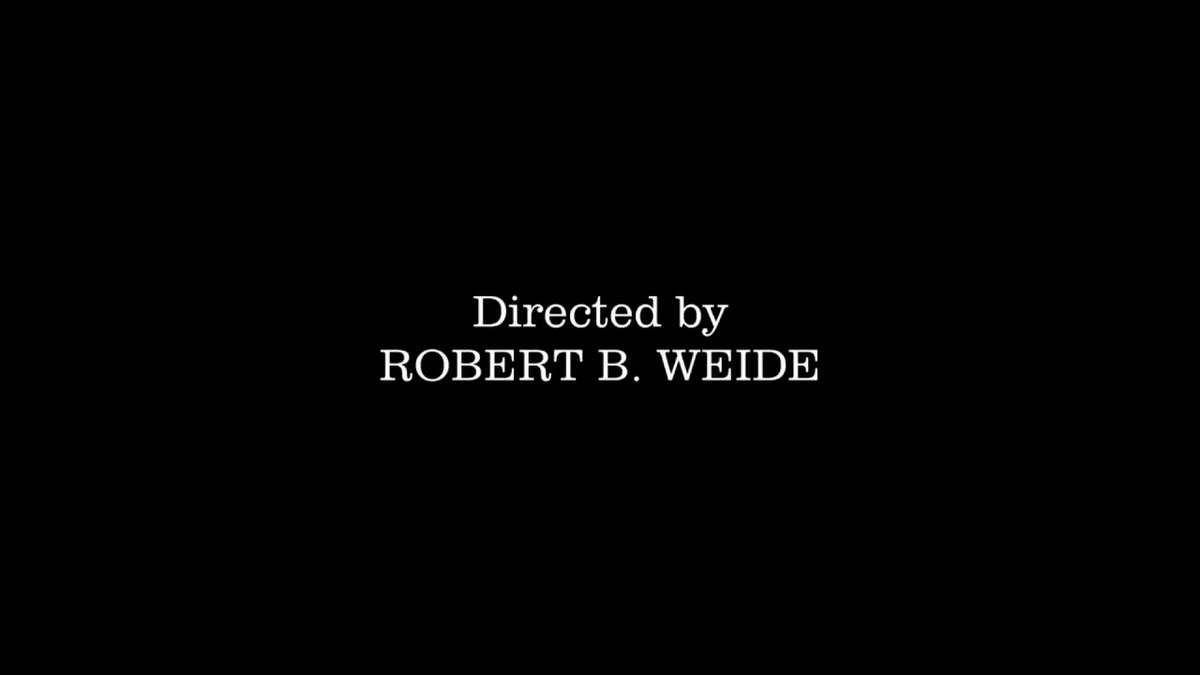

Call me maybe!! tg: @xufana